#### Purpose of this notebook

Once corrected the outliers, the distribution in salaries (without applying log) is more symmetric. Try then the regression directly over the salary, without taking logs, to see whether there is a difference/improvement.

 #### Colab/Local config & libraries

In [1]:
import os

In [2]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

In [3]:
# Change directory
# dir_path = '/content/drive/MyDrive/Web Analytics/Linkedin code/'
dir_path = 'C:/Users/adeli/Documents 4-Q1/Web Analytics/Final Project GitHub/web-analytics-project-repo/'
os.chdir(dir_path)
# Check
current_dir = os.getcwd()
print(current_dir)

C:\Users\adeli\Documents 4-Q1\Web Analytics\Final Project GitHub\web-analytics-project-repo


In [4]:
# Check current working directory
current_dir = os.getcwd()
print(current_dir)

C:\Users\adeli\Documents 4-Q1\Web Analytics\Final Project GitHub\web-analytics-project-repo


In [5]:
#!dir

In [6]:
# Libraries to use
# Standard libraries
import pandas as pd
pd.set_option("display.max_columns", None)   # no column truncation
pd.set_option("display.max_rows", None)      # no row truncation
pd.set_option("display.width", None)         # no line-wrapping
pd.set_option("display.max_colwidth", None)
import numpy as np
# import ast
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
# Specific libraries
from sklearn.model_selection import train_test_split
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

In [8]:
# pip install xgboost

#### Load data

In this notebook, we use salaries converted to $/hour.

In [48]:
#### Load the data
# file_name= "jobs_linkedin_parsed.csv"
file_name= "linkedin_converted_salaries_hour_30emb.csv"
df_raw=pd.read_csv(file_name)
df_raw.drop(columns=["description", "nltk_lemmas"]).head()

,offer_id,title,company_name,city,state_code,seniority_level,job_type,job_function,industry,salary_min,salary_max,salary_unit,salary,searched_position,searched_location,applications,hours_a_week,salary_min_hour,salary_max_hour,salary_avg_hour
0,0,Software Engineering Graduate,Hewlett Packard Enterprise,Roseville,CA,Not Applicable,Full-time,Engineering and Information Technology,IT Services and IT Consulting,70000.0,161700.0,year,"$70,000.00/yr - $161,700.00/yr",Software Engineer,Elk Grove,Over 200 applicants,40,33.653846,77.740385,55.697115
1,1,Software Engineer,Veracity Software Inc,Sacramento,CA,Mid-Senior level,Full-time,Other,IT Services and IT Consulting,NaN,NaN,year,NaN,Software Engineer,Elk Grove,Be among the first 25 applicants,40,NaN,NaN,NaN
2,2,Software Engineer,Epic,Elk Grove,CA,Entry level,Full-time,Engineering and Information Technology,Software Development,NaN,NaN,year,NaN,Software Engineer,Elk Grove,197 applicants,40,NaN,NaN,NaN
3,3,Software Engineer,Epic,Sacramento,CA,Entry level,Full-time,Engineering and Information Technology,Software Development,NaN,NaN,year,NaN,Software Engineer,Elk Grove,190 applicants,40,NaN,NaN,NaN
4,4,Software Engineering Intern,Hewlett Packard Enterprise,Roseville,CA,Not Applicable,Full-time,Engineering and Information Technology,IT Services and IT Consulting,35.0,46.0,hour,$35.00/hr - $46.00/hr,Software Engineer,Elk Grove,Over 200 applicants,40,35.000000,46.000000,40.500000


In [49]:
# Take a first look into data
print("====== Number of samples ======")
print("Number of samples: ", len(df_raw))
print("\n====== Check NAs ======")
print(df_raw.isna().sum().to_frame(name="NA_Counts"))

====== Number of samples ======
Number of samples:  10490

====== Check NAs ======
                   NA_Counts
offer_id                   0
title                      0
company_name               0
city                     408
state_code                 0
seniority_level            0
job_type                   0
job_function               5
industry                   1
description                0
salary_min              3673
salary_max              3673
salary_unit                0
salary                  3673
searched_position          0
searched_location          0
applications               0
nltk_lemmas                0
hours_a_week               0
salary_min_hour         3673
salary_max_hour         3673
salary_avg_hour         3673


In [50]:
# Check that the dataset has no entries with salary_unit as hour and salary_max > 140
mask_140= (df_raw["salary_unit"] == "hour") & (df_raw["salary_max"] > 140)
df_hour_over_140 = df_raw[mask_140]
print(len(df_hour_over_140))

0


#### Study the salary distribution

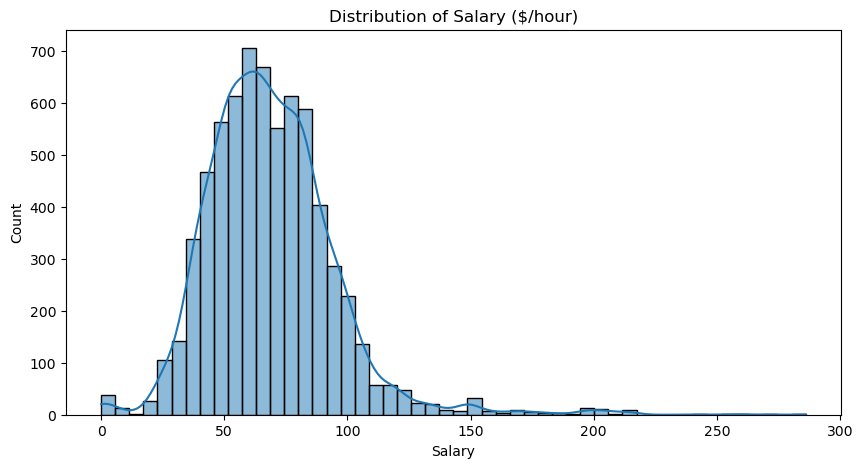

In [ ]:
# Plot salary distribution for 'salary_avg_hour'
salary = df["salary_avg_hour"].dropna()

plt.figure(figsize=(10, 5))
sns.histplot(salary, kde=True, bins=50)
plt.title("Distribution of Salary ($/hour)")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

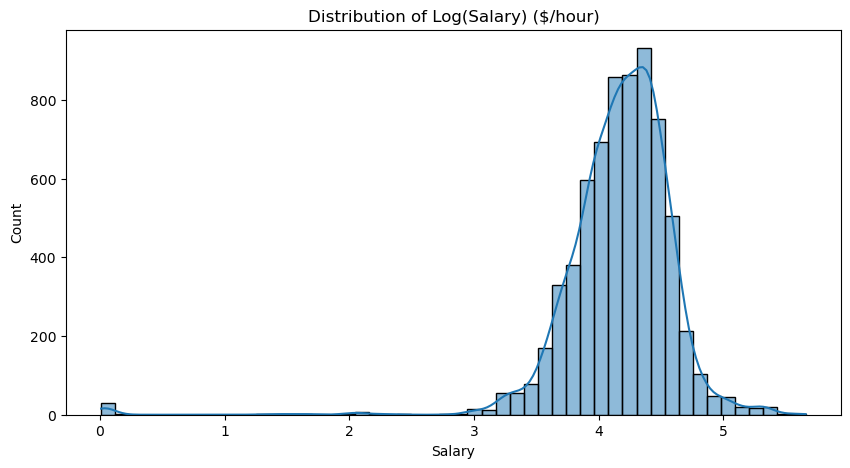

In [ ]:
# Plot logsalary distribution for 'salary_avg_hour'
log_salary = df["salary_avg_hour_log"].dropna()

plt.figure(figsize=(10, 5))
sns.histplot(log_salary, kde=True, bins=50)
plt.title("Distribution of Log(Salary) ($/hour)")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

Once corrected the outliers (8 identified entries that had (from scrapped data)salary unit to hour when it should have been year), the distribution is more symmetric.

#### Feature selection

In [ ]:
# Perform several transformations to prepare data for an XGBoost model

In [51]:
# Examine the meaning of 'Not Applicable' in 'seniority_level'
df_raw[df_raw["seniority_level"]=='Not Applicable'].drop(columns=["description", "nltk_lemmas"]).head()

# See that 'Not Applicable' in 'seniority_level' means entry level jobs, then meaningful, so we keep it as a category

,offer_id,title,company_name,city,state_code,seniority_level,job_type,job_function,industry,salary_min,salary_max,salary_unit,salary,searched_position,searched_location,applications,hours_a_week,salary_min_hour,salary_max_hour,salary_avg_hour
0,0,Software Engineering Graduate,Hewlett Packard Enterprise,Roseville,CA,Not Applicable,Full-time,Engineering and Information Technology,IT Services and IT Consulting,70000.0,161700.0,year,"$70,000.00/yr - $161,700.00/yr",Software Engineer,Elk Grove,Over 200 applicants,40,33.653846,77.740385,55.697115
4,4,Software Engineering Intern,Hewlett Packard Enterprise,Roseville,CA,Not Applicable,Full-time,Engineering and Information Technology,IT Services and IT Consulting,35.0,46.0,hour,$35.00/hr - $46.00/hr,Software Engineer,Elk Grove,Over 200 applicants,40,35.000000,46.000000,40.500000
16,16,Firmware Engineer Graduate,Hewlett Packard Enterprise,Roseville,CA,Not Applicable,Full-time,Engineering and Information Technology,IT Services and IT Consulting,70000.0,161700.0,year,"$70,000.00/yr - $161,700.00/yr",Software Engineer,Elk Grove,187 applicants,40,33.653846,77.740385,55.697115
17,17,Cloud Engineer Graduate,Hewlett Packard Enterprise,Roseville,CA,Not Applicable,Full-time,Engineering and Information Technology,IT Services and IT Consulting,79700.0,183200.0,year,"$79,700.00/yr - $183,200.00/yr",Software Engineer,Elk Grove,Over 200 applicants,40,38.317308,88.076923,63.197115
28,28,Cloud Engineer Intern,Hewlett Packard Enterprise,Roseville,CA,Not Applicable,Full-time,Engineering and Information Technology,IT Services and IT Consulting,35.0,46.0,hour,$35.00/hr - $46.00/hr,Software Engineer,Elk Grove,120 applicants,40,35.000000,46.000000,40.500000


In [52]:
# Select categorical columns to encode before XGBoost
# This encoding is preferred to OneHotEncoding since XGBoost can handle categorical variables as integer codes
categorical_cols = [
    "title",
    "company_name",
    "city",
    "seniority_level",
    "job_type",
    "job_function",
    "industry"
]

# Create a copy of X to encode categorical variables
df=df_raw.copy()
for col in categorical_cols:
    df[col] = df[col].astype("category").cat.codes

In [53]:
# Embeddings are stored as strings, need to convert to arrays
def parse_embedding(text):
    if pd.isna(text):
        return None  # or np.full(300, np.nan)

    s = str(text).strip()
    # After visual inspection of an embedding, need to fix:
    # Remove start/end quotes if present
    if len(s) >= 2 and s[0] == s[-1] and s[0] in ("'", '"'):
        s = s[1:-1]

    # Replace escaped and real newlines with spaces
    s = s.replace("\\r\\n", " ").replace("\r\n", " ")

    # Remove brackets
    s = s.replace("[", " ").replace("]", " ")

    # Split on whitespace and convert to floats
    parts = s.split()
    return np.array([float(p) for p in parts], dtype=float)

# Apply to the column
emb_series = df["description"].apply(parse_embedding)

In [54]:
# To check whether the parsing worked correctly
sample_raw = df["description"].iloc[0]
parsed = parse_embedding(sample_raw)

print(type(parsed))          # <class 'numpy.ndarray'>
print(parsed.shape)          # (300,)
print(parsed[:5])            # first 5 numbers

<class 'numpy.ndarray'>
(30,)
[-0.00664755 -0.32052788  0.08075275  0.18471694  0.35899568]


In [55]:
# Apply over the df once checked above
emb_series = df["description"].apply(parse_embedding)
emb_matrix = np.vstack(emb_series.values)
emb_cols = [f"desc_emb_{i}" for i in range(emb_matrix.shape[1])]
emb_df = pd.DataFrame(emb_matrix, columns=emb_cols, index=df.index)

df = pd.concat([df.drop(columns=["description"]), emb_df], axis=1)

In [56]:
df.drop(columns=["nltk_lemmas"]).head()

,offer_id,title,company_name,city,state_code,seniority_level,job_type,job_function,industry,salary_min,salary_max,salary_unit,salary,searched_position,searched_location,applications,hours_a_week,salary_min_hour,salary_max_hour,salary_avg_hour,desc_emb_0,desc_emb_1,desc_emb_2,desc_emb_3,desc_emb_4,desc_emb_5,desc_emb_6,desc_emb_7,desc_emb_8,desc_emb_9,desc_emb_10,desc_emb_11,desc_emb_12,desc_emb_13,desc_emb_14,desc_emb_15,desc_emb_16,desc_emb_17,desc_emb_18,desc_emb_19,desc_emb_20,desc_emb_21,desc_emb_22,desc_emb_23,desc_emb_24,desc_emb_25,desc_emb_26,desc_emb_27,desc_emb_28,desc_emb_29
0,0,5352,1402,243,CA,6,1,59,355,70000.0,161700.0,year,"$70,000.00/yr - $161,700.00/yr",Software Engineer,Elk Grove,Over 200 applicants,40,33.653846,77.740385,55.697115,-0.006648,-0.320528,0.080753,0.184717,0.358996,-0.283619,-0.210952,0.139572,-0.013842,0.007860,0.288865,0.041548,-0.281909,-0.051980,0.010511,0.003837,-0.243952,-0.234280,0.087270,0.229151,-0.041199,-0.096857,0.167370,-0.086627,-0.079419,0.136373,0.065734,-0.108103,-0.122874,0.024089
1,1,4969,3109,244,CA,5,1,184,355,NaN,NaN,year,NaN,Software Engineer,Elk Grove,Be among the first 25 applicants,40,NaN,NaN,NaN,-0.060901,-0.381482,0.037912,0.244887,0.412955,-0.285336,-0.221840,0.211073,0.005807,0.022888,0.086905,-0.028587,-0.205444,-0.066923,0.219991,0.079129,-0.475039,-0.180961,0.151496,0.211960,-0.033176,0.037851,0.109934,-0.020702,-0.042711,0.161446,0.132598,0.018172,-0.046487,-0.182038
2,2,4969,1097,94,CA,2,1,59,617,NaN,NaN,year,NaN,Software Engineer,Elk Grove,197 applicants,40,NaN,NaN,NaN,-0.114054,-0.280744,0.044375,0.135072,0.424305,-0.218497,-0.328707,0.043376,0.073853,0.118842,0.349374,0.159301,-0.253181,-0.014915,0.090797,0.122452,-0.219550,-0.231084,0.046885,0.233643,-0.015601,-0.159020,0.179523,-0.080442,-0.064098,0.080198,0.074576,-0.119091,-0.230804,0.080442
3,3,4969,1097,244,CA,2,1,59,617,NaN,NaN,year,NaN,Software Engineer,Elk Grove,190 applicants,40,NaN,NaN,NaN,-0.114054,-0.280744,0.044375,0.135072,0.424305,-0.218497,-0.328707,0.043376,0.073853,0.118842,0.349374,0.159301,-0.253181,-0.014915,0.090797,0.122452,-0.219550,-0.231084,0.046885,0.233643,-0.015601,-0.159020,0.179523,-0.080442,-0.064098,0.080198,0.074576,-0.119091,-0.230804,0.080442
4,4,5353,1402,243,CA,6,1,59,355,35.0,46.0,hour,$35.00/hr - $46.00/hr,Software Engineer,Elk Grove,Over 200 applicants,40,35.000000,46.000000,40.500000,-0.007213,-0.319056,0.081227,0.182497,0.359801,-0.281166,-0.211213,0.135897,-0.013090,0.005904,0.286802,0.041633,-0.280484,-0.051513,0.010996,0.002963,-0.239572,-0.232852,0.091554,0.226749,-0.039139,-0.098714,0.168415,-0.087411,-0.079543,0.136444,0.067469,-0.107315,-0.124576,0.023521


In [57]:
# As state is always 'CA', does not add information
df = df.drop(columns=["state_code"], errors="ignore")

#### Separate train, test

In [58]:
# Separate dataset in with and without salary
has_salary = df["salary_min"].notna() | df["salary_max"].notna()
df_train_val = df[has_salary].copy()
df_test = df[~has_salary].copy()

In [59]:
df_train_val.drop(columns=["nltk_lemmas"]).head(2)

,offer_id,title,company_name,city,seniority_level,job_type,job_function,industry,salary_min,salary_max,salary_unit,salary,searched_position,searched_location,applications,hours_a_week,salary_min_hour,salary_max_hour,salary_avg_hour,desc_emb_0,desc_emb_1,desc_emb_2,desc_emb_3,desc_emb_4,desc_emb_5,desc_emb_6,desc_emb_7,desc_emb_8,desc_emb_9,desc_emb_10,desc_emb_11,desc_emb_12,desc_emb_13,desc_emb_14,desc_emb_15,desc_emb_16,desc_emb_17,desc_emb_18,desc_emb_19,desc_emb_20,desc_emb_21,desc_emb_22,desc_emb_23,desc_emb_24,desc_emb_25,desc_emb_26,desc_emb_27,desc_emb_28,desc_emb_29
0,0,5352,1402,243,6,1,59,355,70000.0,161700.0,year,"$70,000.00/yr - $161,700.00/yr",Software Engineer,Elk Grove,Over 200 applicants,40,33.653846,77.740385,55.697115,-0.006648,-0.320528,0.080753,0.184717,0.358996,-0.283619,-0.210952,0.139572,-0.013842,0.007860,0.288865,0.041548,-0.281909,-0.051980,0.010511,0.003837,-0.243952,-0.234280,0.087270,0.229151,-0.041199,-0.096857,0.167370,-0.086627,-0.079419,0.136373,0.065734,-0.108103,-0.122874,0.024089
4,4,5353,1402,243,6,1,59,355,35.0,46.0,hour,$35.00/hr - $46.00/hr,Software Engineer,Elk Grove,Over 200 applicants,40,35.000000,46.000000,40.500000,-0.007213,-0.319056,0.081227,0.182497,0.359801,-0.281166,-0.211213,0.135897,-0.013090,0.005904,0.286802,0.041633,-0.280484,-0.051513,0.010996,0.002963,-0.239572,-0.232852,0.091554,0.226749,-0.039139,-0.098714,0.168415,-0.087411,-0.079543,0.136444,0.067469,-0.107315,-0.124576,0.023521


In [61]:
# Leave in X only the feature columns we are interested in
categorical_cols = [
    "title",
    "company_name",
    "city",
    "seniority_level",
    "job_type",
    "job_function",
    "industry"
]

# Generate embedding column names: desc_emb_0 to desc_emb_29
embedding_cols = [f"desc_emb_{i}" for i in range(30)]

# Union of both lists
feature_cols = categorical_cols + embedding_cols

# Keep only feature columns in X
X = df_train_val[feature_cols]
# Set as target the avg salary
y = df_train_val["salary_avg_hour"]


In [62]:
X.head()

,title,company_name,city,seniority_level,job_type,job_function,industry,desc_emb_0,desc_emb_1,desc_emb_2,desc_emb_3,desc_emb_4,desc_emb_5,desc_emb_6,desc_emb_7,desc_emb_8,desc_emb_9,desc_emb_10,desc_emb_11,desc_emb_12,desc_emb_13,desc_emb_14,desc_emb_15,desc_emb_16,desc_emb_17,desc_emb_18,desc_emb_19,desc_emb_20,desc_emb_21,desc_emb_22,desc_emb_23,desc_emb_24,desc_emb_25,desc_emb_26,desc_emb_27,desc_emb_28,desc_emb_29
0,5352,1402,243,6,1,59,355,-0.006648,-0.320528,0.080753,0.184717,0.358996,-0.283619,-0.210952,0.139572,-0.013842,0.007860,0.288865,0.041548,-0.281909,-0.051980,0.010511,0.003837,-0.243952,-0.234280,0.087270,0.229151,-0.041199,-0.096857,0.167370,-0.086627,-0.079419,0.136373,0.065734,-0.108103,-0.122874,0.024089
4,5353,1402,243,6,1,59,355,-0.007213,-0.319056,0.081227,0.182497,0.359801,-0.281166,-0.211213,0.135897,-0.013090,0.005904,0.286802,0.041633,-0.280484,-0.051513,0.010996,0.002963,-0.239572,-0.232852,0.091554,0.226749,-0.039139,-0.098714,0.168415,-0.087411,-0.079543,0.136444,0.067469,-0.107315,-0.124576,0.023521
5,4969,555,244,5,1,59,422,-0.019447,-0.313700,0.083231,0.183089,0.372232,-0.271143,-0.243285,0.105602,0.023909,0.016556,0.258800,-0.002774,-0.308519,-0.057743,0.058190,-0.027821,-0.286216,-0.277543,0.085432,0.246824,-0.053685,-0.106184,0.172839,-0.029421,-0.072400,0.108510,0.111665,-0.083786,-0.168848,0.016810
7,5292,2711,244,5,1,59,617,-0.081918,-0.294144,-0.022197,0.103202,0.431719,-0.288196,-0.183093,0.144092,0.079750,-0.040330,0.228157,0.038388,-0.265782,0.004216,-0.021852,0.061150,-0.312934,-0.210568,0.127555,0.263107,0.021452,-0.124946,0.157916,-0.031391,-0.075101,0.165731,0.151250,0.018303,-0.139440,-0.045182
8,4969,2681,223,2,1,54,174,-0.085082,-0.296107,0.033996,0.165391,0.376116,-0.243836,-0.324834,0.167933,0.046281,-0.029003,0.218859,0.034064,-0.210055,-0.050167,0.065533,0.026331,-0.254255,-0.261529,0.079194,0.228740,-0.017144,-0.073891,0.141444,-0.082497,-0.148620,0.160147,0.141728,-0.039650,-0.155564,-0.031171


In [63]:
y.head()

0    55.697115
4    40.500000
5    62.500000
7    81.730769
8    61.567308
Name: salary_avg_hour, dtype: float64

In [64]:
# Once that we have X and y, we can split into train and validation sets
# Choose 80% for training and 20% for validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=None
)

print(X_train.shape, X_val.shape)

(5453, 37) (1364, 37)


Once we have transformed and selected the columns and separated into X and y, and perform the split into train and validation, we can start the regression process.

### XGBoost

In [65]:
# Import libraries for XGBoost
import xgboost as xgb

In [66]:
# Need to try this approach due to errors exec the .fit method. Likely due to an issue with 
# the version of xgboost installed -> use xgb.train instead of XGBRegressor().
# DMatrix is a data structure that XGBoost uses for storing in an efficient way the data.
# Internally, uses sparse and compact format to optimize memory and speed.
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)


In this regression with target in $/hour, we jump directly to perform a hyperparameter sweep, 
to determine the best hyperparameter combination and run the regression with them.

#### Perform parameter sweep

In this notebook, use of Weight&Biases to perform a parameter sweep.

In [67]:
import wandb
wandb.login()

True

In [68]:
def train_xgb(config=None):
    with wandb.init(config=config):
        cfg = wandb.config

        # XGBoost params from sweep config
        params = {
            "objective": "reg:squarederror",
            "eta": cfg.learning_rate,          # learning rate
            "max_depth": cfg.max_depth,
            "min_child_weight": cfg.min_child_weight,
            "subsample": cfg.subsample,
            "colsample_bytree": cfg.colsample_bytree,
            "lambda": cfg.reg_lambda,          # L2
            "alpha": cfg.reg_alpha,            # L1
            "gamma": cfg.gamma,
            "tree_method": "hist",
            "seed": 42,
        }

        evals_result = {}
        evals = [(dtrain, "train"), (dval, "val")]

        bst = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=cfg.num_boost_round,
            evals=evals,
            early_stopping_rounds=cfg.early_stopping_rounds,
            evals_result=evals_result,
            verbose_eval=False,
        )

        # --- Metrics in Log space ---
        y_val_pred = bst.predict(dval, iteration_range=(0, bst.best_iteration + 1))
        y_val_true = y_val

        mae  = mean_absolute_error(y_val_true, y_val_pred)
        mse  = mean_squared_error(y_val_true, y_val_pred)
        rmse = np.sqrt(mse)
        r2  = r2_score(y_val_true, y_val_pred)

        # For convenience: approximate MAPE in % (log-space)
        approx_mape = (np.exp(mae) - 1) * 100

        # Log everything to W&B
        wandb.log({
            "val_mae": mae,
            "val_rmse": rmse,
            "val_r2": r2,
            "val_approx_mape": approx_mape,
            "best_iteration": bst.best_iteration,
            "best_val_rmse_xgb": float(bst.best_score),  # xgb's rmse
        })

In [69]:
# Give the sweep configuration: only some random combinations will be tried
sweep_config = {
    "method": "bayes",
    "metric": {"name": "val_rmse_log", "goal": "minimize"},
    "parameters": {
        "learning_rate":    {"values": [0.02, 0.03, 0.05]},
        "max_depth":        {"values": [4, 5, 6]},
        "min_child_weight": {"values": [1, 3, 5]},
        "subsample":        {"values": [0.6, 0.7, 0.8]},
        "colsample_bytree": {"values": [0.5, 0.7, 0.8]},
        "reg_alpha":        {"values": [0.0, 0.5, 1.0]},
        "reg_lambda":       {"values": [1.0, 2.0, 3.0]},
        "gamma":            {"values": [0.0, 0.1, 0.3]},
        "num_boost_round":        {"value": 800},
        "early_stopping_rounds":  {"value": 40},
    },
}


Create sweep with ID: ypm6f59j <br>
Sweep URL: https://wandb.ai/100496657-universidad-carlos-iii-de-madrid/salary_prediction_xgb/sweeps/ypm6f59j <br>
Sweep ID: ypm6f59j  <br>

##### Sweeps

In [70]:
# Limit the number of combinations to try
sweep_id = wandb.sweep(sweep_config, project="salary_prediction_xgb")
print("Sweep ID:", sweep_id)
wandb.agent(sweep_id, function=train_xgb, count=100)

Create sweep with ID: ypm6f59j
Sweep URL: https://wandb.ai/100496657-universidad-carlos-iii-de-madrid/salary_prediction_xgb/sweeps/ypm6f59j
Sweep ID: ypm6f59j


wandb: Agent Starting Run: ut3y89j0 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 5
wandb: 	min_child_weight: 5
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 1
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_xgb,▁
val_approx_mape,▁
val_mae,▁
val_r2,▁
val_rmse,▁
best_iteration,799
best_val_rmse_xgb,15.97845
val_approx_mape,4763587.73048
val_mae,10.77136
val_r2,0.6454


wandb: Agent Starting Run: j9lwsf84 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 5
wandb: 	min_child_weight: 5
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_xgb,▁
val_approx_mape,▁
val_mae,▁
val_r2,▁
val_rmse,▁
best_iteration,799
best_val_rmse_xgb,16.00243
val_approx_mape,4611819.91072
val_mae,10.73898
val_r2,0.64433


...

best_iteration,▁
best_val_rmse_xgb,▁
val_approx_mape,▁
val_mae,▁
val_r2,▁
val_rmse,▁
best_iteration,799
best_val_rmse_xgb,16.29373
val_approx_mape,5253423.41978
val_mae,10.86924
val_r2,0.63127


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 3qfc4y7j with config:
wandb: 	colsample_bytree: 0.5
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.3
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 5
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 1
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_xgb,▁
val_approx_mape,▁
val_mae,▁
val_r2,▁
val_rmse,▁
best_iteration,799
best_val_rmse_xgb,16.13549
val_approx_mape,4376830.10013
val_mae,10.68669
val_r2,0.63839


wandb: Agent Starting Run: nwrp4g84 with config:
wandb: 	colsample_bytree: 0.7
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.3
wandb: 	learning_rate: 0.02
wandb: 	max_depth: 5
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_xgb,▁
val_approx_mape,▁
val_mae,▁
val_r2,▁
val_rmse,▁
best_iteration,799
best_val_rmse_xgb,16.79477
val_approx_mape,8675091.88113
val_mae,11.37081
val_r2,0.60824


##### Best hyperparameters

In [71]:
# Once the sweep is finished, get the best run
# User and project values
entity = "100496657-universidad-carlos-iii-de-madrid"
project = "salary_prediction_xgb"
sweep_id = "ypm6f59j"  # At each new sweep, update the latest sweep ID

# Instantiate the W&B API
api = wandb.Api() 

sweep_path = f"{entity}/{project}/{sweep_id}"
sweep = api.sweep(sweep_path)

In [72]:
best_run = sweep.best_run()  # uses the sweep's metric (val_rmse_mean) and goal (minimize)
cfg = best_run.config

BEST_N_ESTIMATORS     = cfg["num_boost_round"]
BEST_MAX_DEPTH        = cfg["max_depth"]
BEST_LR               = cfg["learning_rate"]
BEST_SUBSAMPLE        = cfg["subsample"]
BEST_COLSAMPLE        = cfg["colsample_bytree"]
BEST_MIN_CHILD_WEIGHT = cfg["min_child_weight"]
BEST_REG_LAMBDA       = cfg["reg_lambda"]
BEST_REG_ALPHA        = cfg["reg_alpha"]    
BEST_GAMMA           = cfg["gamma"]
EARLY_STOPPING_ROUNDS = cfg["early_stopping_rounds"]

wandb: Sorting runs by +summary_metrics.val_rmse_log


##### Train model with best hyperparameters combination

In [73]:
# Train model with these best parameters
params_best = {
    "objective": "reg:squarederror",
    "eta": BEST_LR,           # learning_rate
    "max_depth": BEST_MAX_DEPTH,
    "min_child_weight": BEST_MIN_CHILD_WEIGHT,
    "subsample": BEST_SUBSAMPLE,
    "colsample_bytree": BEST_COLSAMPLE,
    "lambda": BEST_REG_LAMBDA,         # reg_lambda
    "alpha": BEST_REG_ALPHA,          # reg_alpha
    "gamma": BEST_GAMMA,
    "tree_method": "hist",
    "seed": 42,
}


In [74]:
# Define a dict to store results
evals_result_best = {}

# Train the model, change to store results
bst_best = xgb.train(
    params=params_best,
    dtrain=dtrain,
    num_boost_round=BEST_N_ESTIMATORS,
    evals=[(dtrain, "train"), (dval, "val")],
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    evals_result=evals_result_best,     
    verbose_eval=50, # Reduce the number of printed lines 
)

[0]	train-rmse:25.77408	val-rmse:26.68952
[50]	train-rmse:20.58175	val-rmse:22.05306
[100]	train-rmse:18.18955	val-rmse:20.11626
[150]	train-rmse:16.73026	val-rmse:19.18724
[200]	train-rmse:15.70729	val-rmse:18.63494
[250]	train-rmse:14.86549	val-rmse:18.23934
[300]	train-rmse:14.20513	val-rmse:17.95418
[350]	train-rmse:13.61692	val-rmse:17.68167
[400]	train-rmse:13.12367	val-rmse:17.52006
[450]	train-rmse:12.62049	val-rmse:17.36867
[500]	train-rmse:12.18891	val-rmse:17.22379
[550]	train-rmse:11.79140	val-rmse:17.12072
[600]	train-rmse:11.41107	val-rmse:17.01558
[650]	train-rmse:11.06723	val-rmse:16.92461
[700]	train-rmse:10.73711	val-rmse:16.86126
[750]	train-rmse:10.39339	val-rmse:16.75088
[799]	train-rmse:10.07100	val-rmse:16.68064


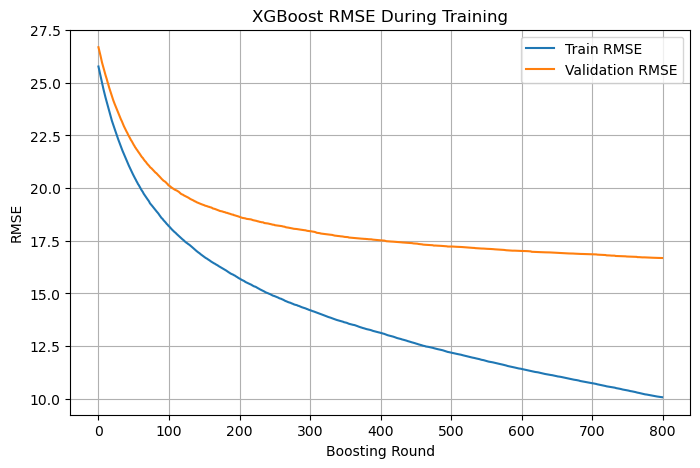

In [75]:
train_rmse = evals_result_best['train']['rmse']
val_rmse   = evals_result_best['val']['rmse']

plt.figure(figsize=(8,5))
plt.plot(train_rmse, label='Train RMSE')
plt.plot(val_rmse,   label='Validation RMSE')
plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.title("XGBoost RMSE During Training")
plt.legend()
plt.grid(True)
plt.show()

In [76]:
best_iter = bst_best.best_iteration
print("Best iteration:", best_iter)
print("Best val score:", bst_best.best_score)


Best iteration: 799
Best val score: 16.680640191396957


In [77]:
y_val_pred = bst_best.predict(dval, iteration_range=(0, best_iter + 1))
y_val_true = y_val

In [78]:
mae = mean_absolute_error(y_val_true, y_val_pred)
mse = mean_squared_error(y_val_true, y_val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val_true, y_val_pred)

print(f"Validation MAE:  {mae:,.0f}")
print(f"Validation RMSE: {rmse:,.0f}")
print(f"Validation R²:   {r2:.3f}")

Validation MAE:  11
Validation RMSE: 17
Validation R²:   0.614


##### Feature importance

In [79]:
# Examine the feature importance of our features in the best model
importance = bst_best.get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'feature': list(importance.keys()),
    'gain': list(importance.values())
}).sort_values('gain', ascending=False)


In [80]:
importance_df

,feature,gain
28,desc_emb_21,12700.422852
3,seniority_level,7957.627930
4,job_type,5835.840820
27,desc_emb_20,5773.892578
10,desc_emb_3,5414.591797
26,desc_emb_19,4820.164062
15,desc_emb_8,3865.631348
5,job_function,3563.333008
6,industry,3433.490234
35,desc_emb_28,3127.869141


In [81]:
# Reminder of number of features used in dtrain (Dmatrix)
num_cols = dtrain.num_col()
print("Number of features used in DMatrix:", num_cols)

Number of features used in DMatrix: 37


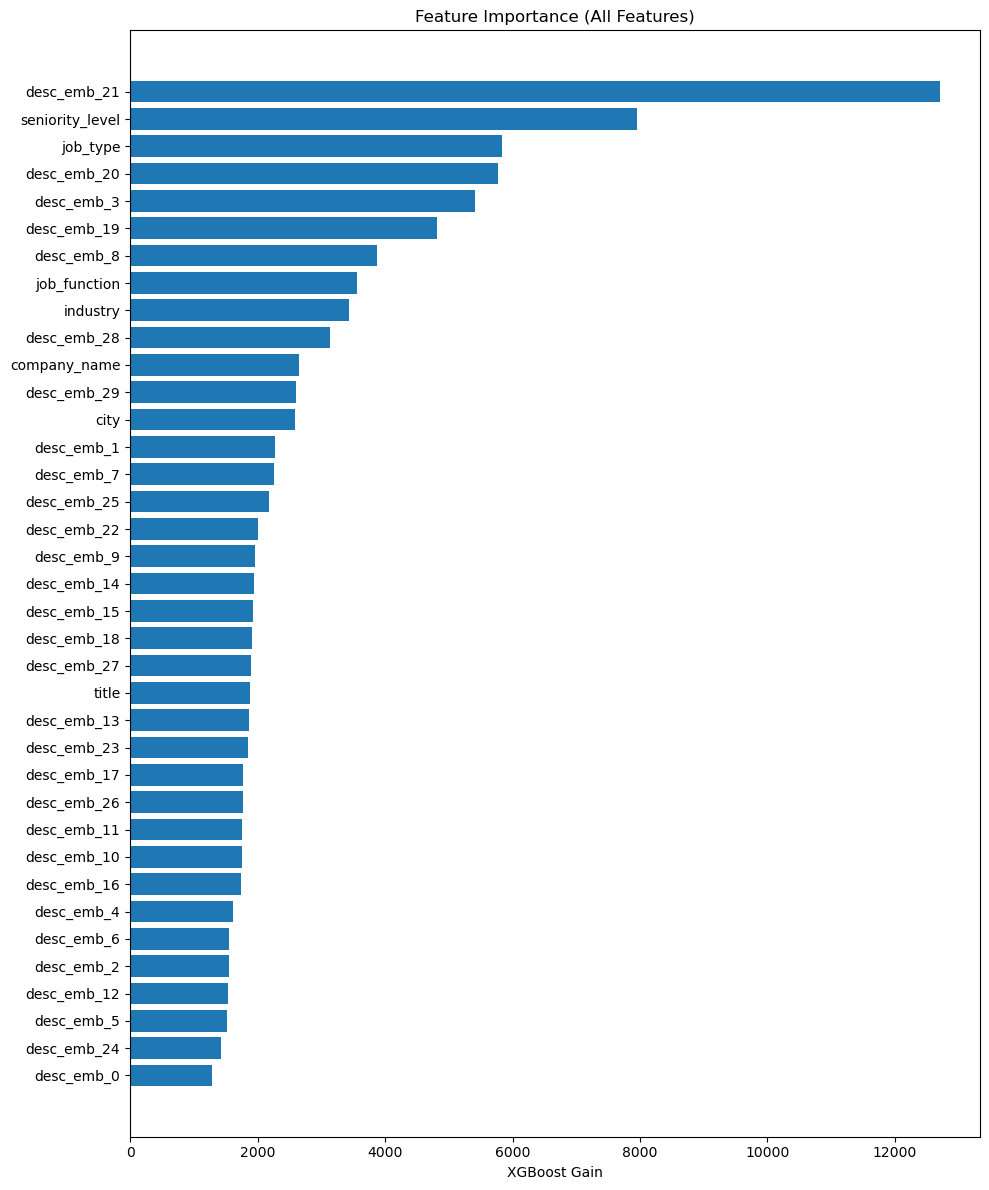

In [82]:
# Plot feature importance for all dimensions
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 12))
plt.barh(importance_df['feature'], importance_df['gain'])
plt.xlabel("XGBoost Gain")
plt.title("Feature Importance (All Features)")
plt.gca().invert_yaxis()  # highest importance at the top
plt.tight_layout()
plt.show()



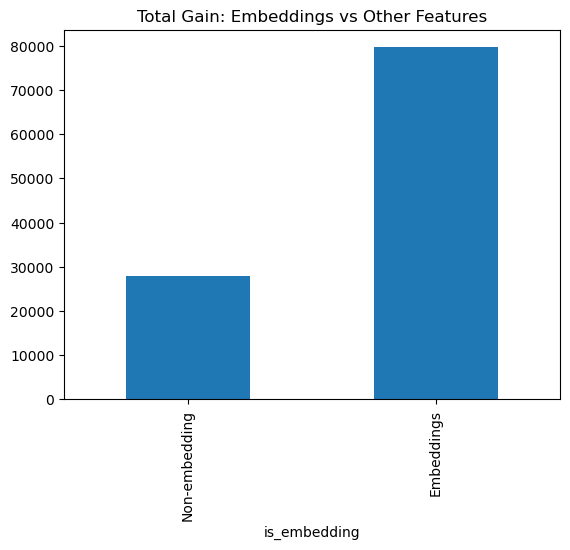

In [83]:
# Check importance of embeddings vs other features (through cumulative gain)
embed_cols = [col for col in df.columns if col.startswith("desc_emb_")]
importance_df['is_embedding'] = importance_df['feature'].isin(embed_cols)

importance_grouped = (
    importance_df
    .groupby('is_embedding')['gain']
    .sum()
    .rename({True: "Embeddings", False: "Non-embedding"})
)

importance_grouped.plot(kind='bar')
plt.title("Total Gain: Embeddings vs Other Features")
plt.show()


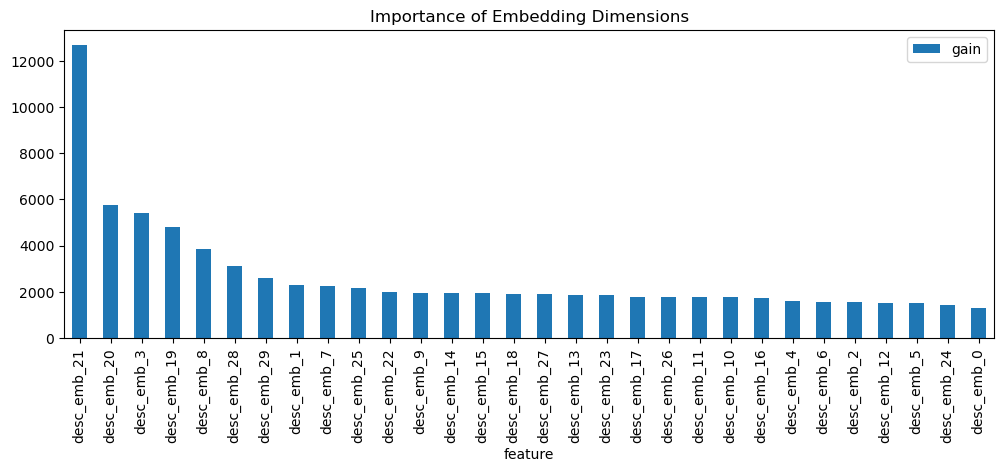

In [84]:
# Plot feature importance for embedding dimensions
embed_importance = importance_df[importance_df['feature'].isin(embed_cols)]
embed_importance = embed_importance.sort_values('gain', ascending=False)

embed_importance.plot(kind='bar', x='feature', y='gain', figsize=(12,4))
plt.title("Importance of Embedding Dimensions")
plt.show()

#### Feature importance with SHAP

In [85]:
# Import SHAP library
import shap

Due to an incompatibility between the installed XGBoost and SHAP versions, cannot use TreeExplainer.
As downgrading both libraries does not guarantee stability wrt sklearn, use instead KernelExplainer. Disadvantage: less exact and slower than TreeExplainer.

Using 500 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/500 [00:00<?, ?it/s]

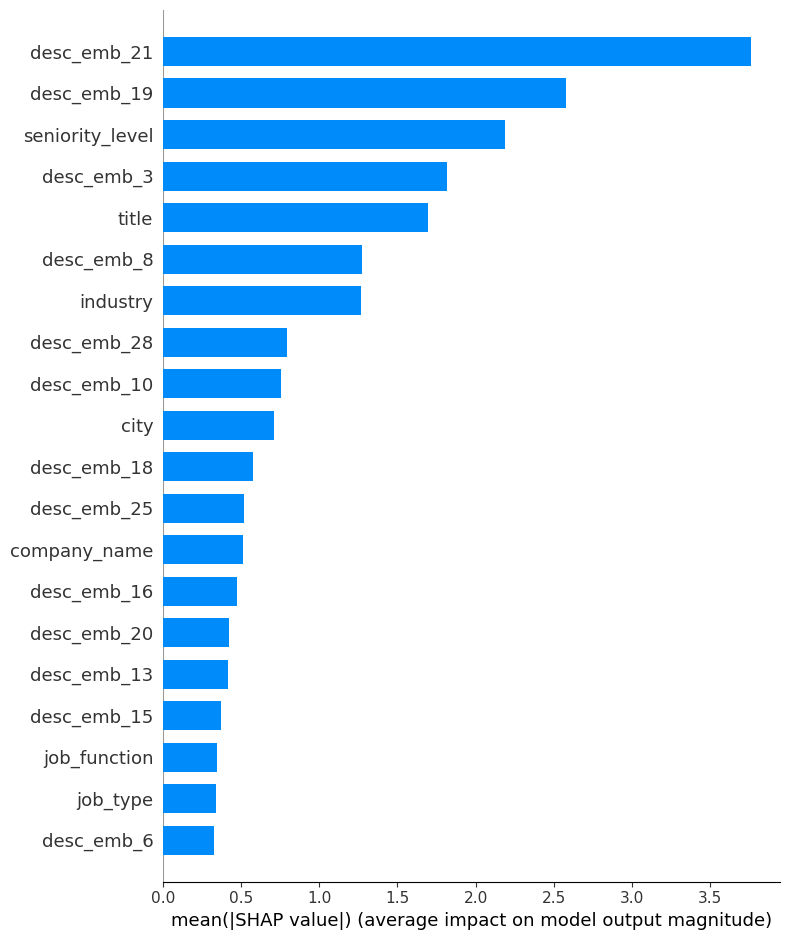

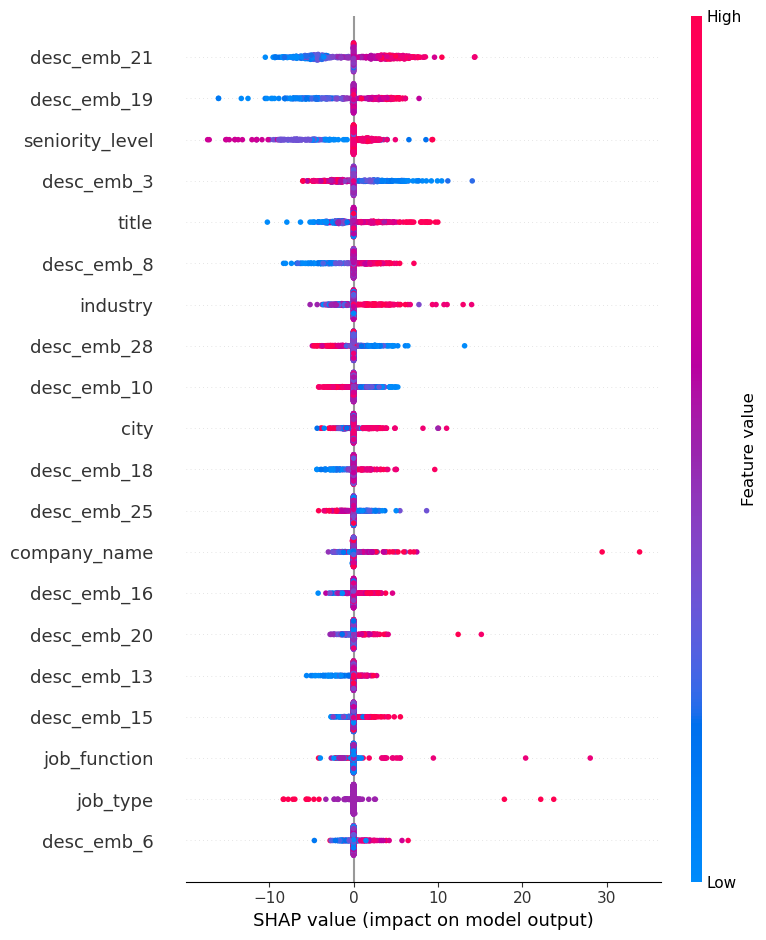

In [86]:
# Define prediction function
def f_predict(X):
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X, columns=X_train.columns)
    d = xgb.DMatrix(X)
    return bst_best.predict(d)

# Background sample
X_bg = X_train.sample(500, random_state=42)

# Explainer
explainer = shap.KernelExplainer(f_predict, X_bg)

# Data to explain
X_shap = X_val.sample(500, random_state=42)

# SHAP values
shap_values = explainer.shap_values(X_shap, nsamples=100)

# Global importance
shap.summary_plot(shap_values, X_shap, plot_type="bar")
shap.summary_plot(shap_values, X_shap)

#### Try regression without the entries that have a range of salaries

In [31]:
df.columns

Index(['offer_id', 'title', 'company_name', 'city', 'seniority_level',
       'job_type', 'job_function', 'industry', 'salary_min', 'salary_max',
       ...
       'desc_emb_291', 'desc_emb_292', 'desc_emb_293', 'desc_emb_294',
       'desc_emb_295', 'desc_emb_296', 'desc_emb_297', 'desc_emb_298',
       'desc_emb_299', 'salary_diff_hour'],
      dtype='object', length=322)

In [32]:
equal_salary_rows = df[df["salary_min_hour"] == df["salary_max_hour"]]

In [34]:
equal_salary_rows.drop(columns=["nltk_lemmas"]).head()

,offer_id,title,company_name,city,seniority_level,job_type,job_function,industry,salary_min,salary_max,salary_unit,salary,searched_position,searched_location,applications,hours_a_week,salary_min_hour,salary_max_hour,salary_avg_hour,salary_avg_hour_log,desc_emb_0,desc_emb_1,desc_emb_2,desc_emb_3,desc_emb_4,desc_emb_5,desc_emb_6,desc_emb_7,desc_emb_8,desc_emb_9,desc_emb_10,desc_emb_11,desc_emb_12,desc_emb_13,desc_emb_14,desc_emb_15,desc_emb_16,desc_emb_17,desc_emb_18,desc_emb_19,desc_emb_20,desc_emb_21,desc_emb_22,desc_emb_23,desc_emb_24,desc_emb_25,desc_emb_26,desc_emb_27,desc_emb_28,desc_emb_29,desc_emb_30,desc_emb_31,desc_emb_32,desc_emb_33,desc_emb_34,desc_emb_35,desc_emb_36,desc_emb_37,desc_emb_38,desc_emb_39,desc_emb_40,desc_emb_41,desc_emb_42,desc_emb_43,desc_emb_44,desc_emb_45,desc_emb_46,desc_emb_47,desc_emb_48,desc_emb_49,desc_emb_50,desc_emb_51,desc_emb_52,desc_emb_53,desc_emb_54,desc_emb_55,desc_emb_56,desc_emb_57,desc_emb_58,desc_emb_59,desc_emb_60,desc_emb_61,desc_emb_62,desc_emb_63,desc_emb_64,desc_emb_65,desc_emb_66,desc_emb_67,desc_emb_68,desc_emb_69,desc_emb_70,desc_emb_71,desc_emb_72,desc_emb_73,desc_emb_74,desc_emb_75,desc_emb_76,desc_emb_77,desc_emb_78,desc_emb_79,desc_emb_80,desc_emb_81,desc_emb_82,desc_emb_83,desc_emb_84,desc_emb_85,desc_emb_86,desc_emb_87,desc_emb_88,desc_emb_89,desc_emb_90,desc_emb_91,desc_emb_92,desc_emb_93,desc_emb_94,desc_emb_95,desc_emb_96,desc_emb_97,desc_emb_98,desc_emb_99,desc_emb_100,desc_emb_101,desc_emb_102,desc_emb_103,desc_emb_104,desc_emb_105,desc_emb_106,desc_emb_107,desc_emb_108,desc_emb_109,desc_emb_110,desc_emb_111,desc_emb_112,desc_emb_113,desc_emb_114,desc_emb_115,desc_emb_116,desc_emb_117,desc_emb_118,desc_emb_119,desc_emb_120,desc_emb_121,desc_emb_122,desc_emb_123,desc_emb_124,desc_emb_125,desc_emb_126,desc_emb_127,desc_emb_128,desc_emb_129,desc_emb_130,desc_emb_131,desc_emb_132,desc_emb_133,desc_emb_134,desc_emb_135,desc_emb_136,desc_emb_137,desc_emb_138,desc_emb_139,desc_emb_140,desc_emb_141,desc_emb_142,desc_emb_143,desc_emb_144,desc_emb_145,desc_emb_146,desc_emb_147,desc_emb_148,desc_emb_149,desc_emb_150,desc_emb_151,desc_emb_152,desc_emb_153,desc_emb_154,desc_emb_155,desc_emb_156,desc_emb_157,desc_emb_158,desc_emb_159,desc_emb_160,desc_emb_161,desc_emb_162,desc_emb_163,desc_emb_164,desc_emb_165,desc_emb_166,desc_emb_167,desc_emb_168,desc_emb_169,desc_emb_170,desc_emb_171,desc_emb_172,desc_emb_173,desc_emb_174,desc_emb_175,desc_emb_176,desc_emb_177,desc_emb_178,desc_emb_179,desc_emb_180,desc_emb_181,desc_emb_182,desc_emb_183,desc_emb_184,desc_emb_185,desc_emb_186,desc_emb_187,desc_emb_188,desc_emb_189,desc_emb_190,desc_emb_191,desc_emb_192,desc_emb_193,desc_emb_194,desc_emb_195,desc_emb_196,desc_emb_197,desc_emb_198,desc_emb_199,desc_emb_200,desc_emb_201,desc_emb_202,desc_emb_203,desc_emb_204,desc_emb_205,desc_emb_206,desc_emb_207,desc_emb_208,desc_emb_209,desc_emb_210,desc_emb_211,desc_emb_212,desc_emb_213,desc_emb_214,desc_emb_215,desc_emb_216,desc_emb_217,desc_emb_218,desc_emb_219,desc_emb_220,desc_emb_221,desc_emb_222,desc_emb_223,desc_emb_224,desc_emb_225,desc_emb_226,desc_emb_227,desc_emb_228,desc_emb_229,desc_emb_230,desc_emb_231,desc_emb_232,desc_emb_233,desc_emb_234,desc_emb_235,desc_emb_236,desc_emb_237,desc_emb_238,desc_emb_239,desc_emb_240,desc_emb_241,desc_emb_242,desc_emb_243,desc_emb_244,desc_emb_245,desc_emb_246,desc_emb_247,desc_emb_248,desc_emb_249,desc_emb_250,desc_emb_251,desc_emb_252,desc_emb_253,desc_emb_254,desc_emb_255,desc_emb_256,desc_emb_257,desc_emb_258,desc_emb_259,desc_emb_260,desc_emb_261,desc_emb_262,desc_emb_263,desc_emb_264,desc_emb_265,desc_emb_266,desc_emb_267,desc_emb_268,desc_emb_269,desc_emb_270,desc_emb_271,desc_emb_272,desc_emb_273,desc_emb_274,desc_emb_275,desc_emb_276,desc_emb_277,desc_emb_278,desc_emb_279,desc_emb_280,desc_emb_281,desc_emb_282,desc_emb_283,desc_emb_284,desc_emb_285,desc_emb_286,desc_emb_287,desc_emb_288,desc_emb_289,desc_emb_290,desc_emb_291,desc_emb_292,desc_emb_293,desc_emb_294,desc_emb_295,desc_emb_2

In [35]:
len(equal_salary_rows)

43

##### Try with the job titles

In [37]:
df_titles= pd.read_csv("role_family_mapping.csv")

In [38]:
df_titles.columns

Index(['title', 'role_family'], dtype='object')

In [45]:
df["title_family"] = df_titles["role_family"]

In [46]:
df.columns

Index(['offer_id', 'title', 'company_name', 'city', 'state_code',
       'seniority_level', 'job_type', 'job_function', 'industry',
       'description', 'salary_min', 'salary_max', 'salary_unit', 'salary',
       'searched_position', 'searched_location', 'applications', 'nltk_lemmas',
       'hours_a_week', 'salary_min_hour', 'salary_max_hour', 'salary_avg_hour',
       'salary_avg_hour_log', 'title_family'],
      dtype='object')

In [48]:
categorical_cols = [
    'title_family'
]

# Create a copy of  to encode categorical variables
df_family=df.copy()
for col in categorical_cols:
    df_family[col] = df_family[col].astype("category").cat.codes

In [51]:
# Separate dataset in with and without salary
has_salary = df_family["salary_min"].notna() | df_family["salary_max"].notna()
df_train_val = df_family[has_salary].copy()
df_test = df_family[~has_salary].copy()

In [50]:
# LEave in X only the feature columns we are interested in
categorical_cols = [
    "title_family",
    "company_name",
    "city",
    "seniority_level",
    "job_type",
    "job_function",
    "industry"
]

# Generate embedding column names: desc_emb_0 to desc_emb_299
embedding_cols = [f"desc_emb_{i}" for i in range(300)]

# Union of both lists
feature_cols = categorical_cols + embedding_cols

# Keep only feature columns in X
X = df_train_val[feature_cols]
# Set as target the log avg salary
y = df_train_val["salary_avg_hour_log"]
# y = df_train_val["salary_avg_hour_log"] # To try predicting the real salary instead of log

KeyError: "['desc_emb_0', 'desc_emb_1', 'desc_emb_2', 'desc_emb_3', 'desc_emb_4', 'desc_emb_5', 'desc_emb_6', 'desc_emb_7', 'desc_emb_8', 'desc_emb_9', 'desc_emb_10', 'desc_emb_11', 'desc_emb_12', 'desc_emb_13', 'desc_emb_14', 'desc_emb_15', 'desc_emb_16', 'desc_emb_17', 'desc_emb_18', 'desc_emb_19', 'desc_emb_20', 'desc_emb_21', 'desc_emb_22', 'desc_emb_23', 'desc_emb_24', 'desc_emb_25', 'desc_emb_26', 'desc_emb_27', 'desc_emb_28', 'desc_emb_29', 'desc_emb_30', 'desc_emb_31', 'desc_emb_32', 'desc_emb_33', 'desc_emb_34', 'desc_emb_35', 'desc_emb_36', 'desc_emb_37', 'desc_emb_38', 'desc_emb_39', 'desc_emb_40', 'desc_emb_41', 'desc_emb_42', 'desc_emb_43', 'desc_emb_44', 'desc_emb_45', 'desc_emb_46', 'desc_emb_47', 'desc_emb_48', 'desc_emb_49', 'desc_emb_50', 'desc_emb_51', 'desc_emb_52', 'desc_emb_53', 'desc_emb_54', 'desc_emb_55', 'desc_emb_56', 'desc_emb_57', 'desc_emb_58', 'desc_emb_59', 'desc_emb_60', 'desc_emb_61', 'desc_emb_62', 'desc_emb_63', 'desc_emb_64', 'desc_emb_65', 'desc_em

#### Evaluation over all train+val

In [45]:
# Re-run as the variables X and y must have been modified after initial definition and get error
# Keep only feature columns in X
X = df_train_val[feature_cols]
# Set as target the log avg salary
y = df_train_val["salary_avg_hour_log"]

In [46]:
# Train the model over the full labeled dataset
X_full = X.values             # df_train_val[feature_cols]
y_full_log = y.values            # df_train_val["salary_avg_year_log"]

"""print("Right after assignment:")
print(y_full_log[:10])
print(y.values[:10])"""

dtrain_full = xgb.DMatrix(X_full, label=y_full_log)

# Use best_iter + 1 trees, no early stopping (we already validated)
bst_final = xgb.train(
    params=params_best,
    dtrain=dtrain_full,
    num_boost_round=best_iter + 1,
    evals=[(dtrain_full, "train")],
    verbose_eval=50,
)

print("Final model trained with", best_iter + 1, "trees.")


[0]	train-rmse:0.52582
[50]	train-rmse:0.37375
[100]	train-rmse:0.29786
[150]	train-rmse:0.25138
[200]	train-rmse:0.21672
[250]	train-rmse:0.19060
[300]	train-rmse:0.16893
[350]	train-rmse:0.15109
[400]	train-rmse:0.13483
[450]	train-rmse:0.12087
[500]	train-rmse:0.10876
[550]	train-rmse:0.09892
[600]	train-rmse:0.08932
[650]	train-rmse:0.08060
[700]	train-rmse:0.07280
[750]	train-rmse:0.06583
[799]	train-rmse:0.05982
Final model trained with 800 trees.


#### Prediction

In [ ]:
# Missing:ensure which transformations were applied to X_test before predicting

In [146]:
# Build test feature matrix with the same columns
X_test = df_test[feature_cols].copy()
dtest  = xgb.DMatrix(X_test)

# Predict in log space
y_test_pred_log = bst_final.predict(dtest)

# Convert back to yearly salary
y_test_pred_year = np.exp(y_test_pred_log)

# Attach to df_test
df_test["pred_salary_avg_year_log"] = y_test_pred_log
df_test["pred_salary_avg_year"]     = y_test_pred_year

df_test[["pred_salary_avg_year"]].head()


,pred_salary_avg_year
1,77203.789062
2,55070.183594
3,60832.625000
6,60832.625000
9,95252.984375


In [ ]:
# Perform over df_test the transformations we did over df_train_val
# LEave in X only the feature columns we are interested in
categorical_cols = [
    "title",
    "company_name",
    "city",
    "seniority_level",
    "job_type",
    "job_function",
    "industry"
]

# Generate embedding column names: desc_emb_0 to desc_emb_299
embedding_cols = [f"desc_emb_{i}" for i in range(300)]

# Union of both lists
feature_cols = categorical_cols + embedding_cols

# Keep only feature columns in X
X_test = df_test[feature_cols]
# Set as target the log avg salary
y_test = df_test["salary_avg_year_log"]
# y_test = df_test["salary_avg_year"] # To try predicting the real salary instead of log

In [94]:
dtest = xgb.DMatrix(X_test)

In [95]:
y_test_pred_log = bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1))


In [96]:
y_test_pred_year = np.exp(y_test_pred_log)

In [98]:
y_test_pred_year[:20]

array([ 75074.51 ,  60179.84 ,  59749.28 ,  59749.28 , 101151.625,
       166183.1  , 174647.03 , 149247.83 ,  93899.53 , 172768.8  ,
       105643.28 , 155959.22 , 214936.34 , 162036.95 , 123014.26 ,
       189970.83 , 172083.42 , 144138.31 ,  57662.883, 162140.2  ],
      dtype=float32)

In [60]:
# Convert back to original salary scale (undo log)
y_val_true = np.expm1(y_val)
y_val_pred = np.expm1(y_val_pred_log)


In [61]:
mae = mean_absolute_error(y_val_true, y_val_pred)
mse = mean_squared_error(y_val_true, y_val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val_true, y_val_pred)

print(f"Validation MAE:  {mae:,.0f}")
print(f"Validation RMSE: {rmse:,.0f}")
print(f"Validation R²:   {r2:.3f}")

Validation MAE:  127,791
Validation RMSE: 3,612,063
Validation R²:   0.608


In [ ]:
# Need to run once we have to full dataset, with converted salaries and WE for the description

#### Final code parsing Linkedin json

In [ ]:
# Purpose of the notebook: parse json schema returned by the Linkedin scraper
# OBS: not finished to parse:
# Libraries to use
# Standard libraries
import pandas as pd
pd.set_option("display.max_columns", None)   # no column truncation
pd.set_option("display.max_rows", None)      # no row truncation
pd.set_option("display.width", None)         # no line-wrapping
pd.set_option("display.max_colwidth", None)
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
# Specific libraries
import json
from pathlib import Path
import re

# Create the mapping dictionary from text name of state to state code. OBS: not needed for now
state_map = {
    "california": "CA"
}

# Recover file name
file_solvang = "EngineerJobs_ByLocation_Solvang.json"
path = Path(file_solvang)

with path.open("r", encoding="utf-8") as f:
    data = json.load(f)               # expects a list[dict]

# If it's a single dict, make it a list
if isinstance(data, dict):
    data = [data]

# Flatten nested fields (company.name -> company_name)
df = pd.json_normalize(data, sep=".")

# Create offer ID using the index (checked that it is unique)
df["offer_id"] = df.index

# EXTRACT CRITERIA INFORMATION INTO COLUMNS
# Explode the criteria column: extract the content of the dict in four columns
df["criteria_dict"] = df["criteria"].apply(
    lambda lst: {d["name"]: d["value"] for d in lst}
)
criteria_expanded = df["criteria_dict"].apply(pd.Series)

df = pd.concat([df, criteria_expanded], axis=1)
df = df.drop(columns=["criteria", "criteria_dict"])

# RENAME AND REORDER COLUMNS
# Rename columns to have the same naming criteria
df = df.rename(columns={
    "company.name": "company_name",
    "company.url": "company_url",
    "Seniority level": "seniority_level",
    "Employment type": "job_type",
    "Job function": "job_function",
    "Industries": "industry"
})

# Reorder the cols as we want them
"""ordered = ['offer_id', "title", "company_name", "location", "salary",
           "description", "url", 'criteria', "seniority_level",'job_type',
           'job_function','industry','searched_position', 'searched_location',
           'applications', 'company_url']
df=df[ordered]"""

# PARSE SALARY INFORMATION
# Ensure None are numpy NaN
df["salary"] = df["salary"].replace([None, "None", ""], np.nan)

# User regular expressions to extract the information we want from the current salary column
# We define first dicts that contain the unit patterns we want to detect
_unit_patterns = [
    (r"\b(per|an|a)\s+hour\b|/hour|/hr|\bhr\b|\bhour\b", "hour"),
    (r"\b(per|an|a)\s+year\b|/year|\byr\b|\byear\b|\bannum\b", "year"),
    (r"\b(per|an|a)\s+month\b|/month|\bmo\b|\bmonth\b", "month"),
    (r"\b(per|an|a)\s+week\b|/week|\bwk\b|\bweek\b", "week"),
    # Did not see for now salaries by day, otherwise, add
]
# Same for the digits
_num_pattern = re.compile(
    r"\$?\s*([0-9]{1,3}(?:,[0-9]{3})*(?:\.[0-9]+)?|[0-9]+(?:\.[0-9]+)?)"
)

# Function to detect the unit of time the salary is given in
def _detect_unit(text_lower):
    for pattern, unit in _unit_patterns:
        if re.search(pattern, text_lower):
            return unit
    return pd.NA

# Function to parse the content of the current salary column
def parse_salary_cell(s):
    """
    Returns (min_val, max_val, unit) where min/max are floats (NaN if not found),
    and unit in {'hour','month','year','week', NA}.
    """
    if pd.isna(s):
        return np.nan, np.nan, pd.NA
    # Remove from the string whitespaces and convert to lower case
    txt = str(s).strip()
    txt_lower = txt.lower()

    # Find all numeric parts in the string
    nums = [float(n.replace(",", "")) for n in _num_pattern.findall(txt)]
    if not nums:
        return np.nan, np.nan, _detect_unit(txt_lower)

    # If we recover one number, assign to both min and max
    # If we recover two numbers, assing as corresponds to min and max
    if len(nums) >= 2:
        low, high = sorted(nums[:2])
    else:
        low = high = nums[0]

    unit = _detect_unit(txt_lower)
    return low, high, unit

# Apply to the column and create the new columns
parsed = df["salary"].apply(parse_salary_cell)
df[["salary_min", "salary_max", "salary_unit"]] = pd.DataFrame(parsed.tolist(), index=df.index)

# PARSE LOCATION INFORMATION
# Extract from location the city and the US state
# Initialize columns
df["city"] = pd.NA
df["state"] = pd.NA

# Split location first
splits = df["location"].str.split(",")

# Compute len per row
len_location = splits.str.len()
# In first Linkedin json only get location with 2 splits, but include the rest of the code in case there are entries
# with only one split as in Indeed data
# If len_location == 1
mask1 = len_location == 1
df.loc[mask1, "city"] = pd.NA
df.loc[mask1, "state"] = splits.str[-1]
# Over this recovered state name, apply the mapping to encode the state code
df["state"] = (
    df["state"]
    .str.lower()
    .replace(state_map, regex=False)
)
# If len_location > 1
mask2 = len_location > 1
df.loc[mask2, "city"] = splits.str[-2]
df.loc[mask2, "state"] = splits.str[-1]
# Need to remove the postal code
df["state_code"] = df["state"].str.split().str[0]

# CODE TO TREAT ENTRIES IN WHICH 'salary' DOES NOT CONTAIN SALARY INFORMATION
# Try to capture the entries where salary is not None or contains a $ -> these are entries where there is
# another information in salary. May be usueful.
df_no_dollar = df[
    df["salary"].apply(lambda x: isinstance(x, str)) &
    ~df["salary"].str.contains(r"\$", na=False)
].copy()

df_no_dollar = df_no_dollar[["offer_id", "salary"]].rename(
    columns={"salary": "useful_type"}
)
len_df_no_dollar = len(df_no_dollar)
print(f"Number of entries with no salary information in 'salary' column: {len_df_no_dollar}")

# If len_df_no_dollar is not 0
if len_df_no_dollar != 0:
    df = df.merge(df_no_dollar, on="offer_id", how="left")
    # Now extract information from job_type: eliminate 'Job type '
    df["job_type"] = df["job_type"].str.replace("Job type ", "", regex=False)

    # Compare job_type and useful_type (information previously extracted from 'salary'
    # when its content is not in fact a salary). Create a col to store the comparison.
    df["job_vs_useful_match"] = None

    mask = df["useful_type"].notna()
    df.loc[mask, "job_vs_useful_match"] = (
        df.loc[mask, "job_type"] == df.loc[mask, "useful_type"]
    )
    # Print the values of 'job_vs_useful_match'. If all True and the same number than
    # "Number of entries with no salary information in 'salary' column: ", the information in
    # useful_type is the same than the one contained in "job_type".
    counts = df.value_counts("job_vs_useful_match")[True]

    # Print the values of 'job_vs_useful_match'. If all True and the same number than
    # "Number of entries with no salary information in 'salary' column: ", the information in
    # useful_type is the same than the one contained in "job_type".
    counts = df.value_counts("job_vs_useful_match")[True]
    print("Number of entries with the same content in useful_type than in job_type: ", counts)
    print("If same number, columns useful_type and job_vs_useful_match can be dropped from df")

# SAVE URL to OFFER_ID AND DROP
# Before dropping 'url', store csv with offer_id, url in case it is useful in the future.
df[["offer_id", "url"]].to_csv("offer_id_url_Linkedin.csv", index=False)

# DROP, REORDER AND STORE DF into CSV
# Columns determined to be non-useful are dropped: url, company_url, pay
df.drop(columns=["url", "company_url", "state", "location"], inplace=True)

# Reorder the df into our preferred order
print("Num cols before reordering: ", len(df.columns))
ordered = ['offer_id', "title", "company_name", 'city', 'state_code','seniority_level',
           'job_type', 'job_function', 'industry',
           "description", 'salary_min', 'salary_max', 'salary_unit',"salary",
           'searched_position', 'searched_location', 'applications']
print("Num cols after reordering: ", len(ordered))

df = df[ordered]
# To save
file_name= "jobs_linkedin_solvang.csv"
df.to_csv(file_name, index=False)
print(f"Data has been saved to file: {file_name}")

Number of entries with no salary information in 'salary' column: 0
Num cols before reordering:  17
Num cols after reordering:  17
Data has been saved to file: jobs_linkedin_solvang.csv


In [ ]:
df.columns

Index(['offer_id', 'title', 'company_name', 'city', 'state_code',
       'seniority_level', 'job_type', 'job_function', 'industry',
       'description', 'salary_min', 'salary_max', 'salary_unit', 'salary',
       'searched_position', 'searched_location', 'applications'],
      dtype='object')

In [ ]:
df.drop(columns=['description']).head()

,offer_id,title,company_name,city,state_code,seniority_level,job_type,job_function,industry,salary_min,salary_max,salary_unit,salary,searched_position,searched_location,applications
0,0,Software Developer,Tecolote Research,Goleta,CA,Entry level,Full-time,Information Technology,Business Consulting and Services and Space Research and Technology,55000.0,70000.0,year,"$55,000.00/yr - $70,000.00/yr",Software Engineer,Solvang,Over 200 applicants
1,1,Software Engineer,Teledyne Technologies Incorporated,Goleta,CA,Mid-Senior level,Full-time,Engineering and Information Technology,Software Development,NaN,NaN,<NA>,NaN,Software Engineer,Solvang,Over 200 applicants
2,2,Software Engineer,Digital Prospectors,Goleta,CA,Mid-Senior level,Contract,Information Technology and Manufacturing,"Software Development, Defense and Space Manufacturing, and Manufacturing",70.0,80.0,hour,$70.00/hr - $80.00/hr,Software Engineer,Solvang,90 applicants
3,3,Java Spring Microservice,Litmus7,Goleta,CA,Mid-Senior level,Full-time,Engineering and Information Technology,IT Services and IT Consulting,NaN,NaN,<NA>,NaN,Software Engineer,Solvang,Over 200 applicants
4,4,Software Engineer,Toyon Research Corporation,Goleta,CA,Mid-Senior level,Full-time,Engineering and Information Technology,Defense and Space Manufacturing,90000.0,140000.0,year,"$90,000.00/yr - $140,000.00/yr",Software Engineer,Solvang,135 applicants


In [ ]:
# Purpose of the notebook: parse json schema returned by the indeed scraper
# OBS: not finished to parse: 'shift_schedule', 'work_setting'
# Libraries to use
# Standard libraries
import pandas as pd
pd.set_option("display.max_columns", None)   # no column truncation
pd.set_option("display.max_rows", None)      # no row truncation
pd.set_option("display.width", None)         # no line-wrapping
pd.set_option("display.max_colwidth", None)
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
# Specific libraries
import json
from pathlib import Path
import re

# Create the mapping dictionary from text name of state to state code
state_map = {
    "california": "CA"
}

path = Path("indeed_jobs.json")

with path.open("r", encoding="utf-8") as f:
    data = json.load(f)               # expects a list[dict]

# If it's a single dict, make it a list
if isinstance(data, dict):
    data = [data]

# Flatten nested fields (company.name -> company_name)
df = pd.json_normalize(data, sep=".")

# Create offer ID using the index (checked that it is unique)
df["offer_id"] = df.index
# Rename columns to have the same naming criteria
df = df.rename(columns={
    "company.name": "company_name",
    "company.url": "company_url",
    "criteria.Pay": "pay",
    "criteria.Job type": "job_type",
    "criteria.Shift and schedule": "shift_schedule",
    "criteria.Work setting": "work_setting"
})
# Reorder
cols_order=["offer_id", "title", "company_name", "location", "salary", 'pay', 'job_type', 'shift_schedule', 'work_setting', "description","url", "company_url"]
df=df[cols_order]

# Ensure core columns exist even if missing in some entries
for col in ["url", "title", "company_name", "company_url", "location", "salary", "description"]:
    if col not in df.columns:
        df[col] = pd.NA

# Ensure None are numpy NaN
df["salary"] = df["salary"].replace([None, "None", ""], np.nan)

# User regular expressions to extract the information we want from the current salary column
# We define first dicts that contain the unit patterns we want to detect
_unit_patterns = [
    (r"\b(per|an|a)\s+hour\b|/hour|/hr|\bhr\b|\bhour\b", "hour"),
    (r"\b(per|an|a)\s+year\b|/year|\byr\b|\byear\b|\bannum\b", "year"),
    (r"\b(per|an|a)\s+month\b|/month|\bmo\b|\bmonth\b", "month"),
    (r"\b(per|an|a)\s+week\b|/week|\bwk\b|\bweek\b", "week"),
    # Did not see for now salaries by day, otherwise, add
]
# Same for the digits
_num_pattern = re.compile(
    r"\$?\s*([0-9]{1,3}(?:,[0-9]{3})*(?:\.[0-9]+)?|[0-9]+(?:\.[0-9]+)?)"
)

# Function to detect the unit of time the salary is given in
def _detect_unit(text_lower):
    for pattern, unit in _unit_patterns:
        if re.search(pattern, text_lower):
            return unit
    return pd.NA

# Function to parse the content of the current salary column
def parse_salary_cell(s):
    """
    Returns (min_val, max_val, unit) where min/max are floats (NaN if not found),
    and unit in {'hour','month','year','week', NA}.
    """
    if pd.isna(s):
        return np.nan, np.nan, pd.NA
    # Remove from the string whitespaces and convert to lower case
    txt = str(s).strip()
    txt_lower = txt.lower()

    # Find all numeric parts in the string
    nums = [float(n.replace(",", "")) for n in _num_pattern.findall(txt)]
    if not nums:
        return np.nan, np.nan, _detect_unit(txt_lower)

    # If we recover one number, assign to both min and max
    # If we recover two numbers, assing as corresponds to min and max
    if len(nums) >= 2:
        low, high = sorted(nums[:2])
    else:
        low = high = nums[0]

    unit = _detect_unit(txt_lower)
    return low, high, unit

# Apply to the column and create the new columns
parsed = df["salary"].apply(parse_salary_cell)
df[["salary_min", "salary_max", "salary_unit"]] = pd.DataFrame(parsed.tolist(), index=df.index)

# Extract from location the city and the US state
# Initialize columns
df["city"] = pd.NA
df["state"] = pd.NA

# Split location first
splits = df["location"].str.split(",")

# Compute len per row
len_location = splits.str.len()

# If len_location == 1
mask1 = len_location == 1
df.loc[mask1, "city"] = pd.NA
df.loc[mask1, "state"] = splits.str[-1]
# Over this recovered state name, apply the mapping to encode the state code
df["state"] = (
    df["state"]
    .str.lower()
    .replace(state_map, regex=False)
)

# If len_location > 1
mask2 = len_location > 1
df.loc[mask2, "city"] = splits.str[-2]
df.loc[mask2, "state"] = splits.str[-1]

# df.drop(columns=["prov"], inplace=True)
# Need to remove the postal code
df["state_code"] = df["state"].str.split().str[0]

# Columns determined to be non-useful are dropped: url, company_url, pay
# However, store csv with offer_id, url in case it is useful in the future.
df[["offer_id", "url"]].to_csv("offer_id_url.csv", index=False)

# Drop
df.drop(columns=["url", "company_url", "state"], inplace=True)

# Try to capture the entries where salary is not None or contains a $ -> these are entries where there is
# another information in salary. May be usueful.
df_no_dollar = df[
    df["salary"].apply(lambda x: isinstance(x, str)) &
    ~df["salary"].str.contains(r"\$", na=False)
].copy()

df_no_dollar = df_no_dollar[["offer_id", "salary"]].rename(
    columns={"salary": "useful_type"}
)
print(f"Number of entries with no salary information in 'salary' column: {len(df_no_dollar)}")
df = df.merge(df_no_dollar, on="offer_id", how="left")

# Now extract information from job_type: eliminate 'Job type '
df["job_type"] = df["job_type"].str.replace("Job type ", "", regex=False)

# Compare job_type and useful_type (information previously extracted from 'salary'
# when its content is not in fact a salary). Create a col to store the comparison.
df["job_vs_useful_match"] = None

mask = df["useful_type"].notna()
df.loc[mask, "job_vs_useful_match"] = (
    df.loc[mask, "job_type"] == df.loc[mask, "useful_type"]
)
# Print the values of 'job_vs_useful_match'. If all True and the same number than
# "Number of entries with no salary information in 'salary' column: ", the information in
# useful_type is the same than the one contained in "job_type".
counts = df.value_counts("job_vs_useful_match")[True]
print("Number of entries with the same content in useful_type than in job_type: ", counts)
print("If same number, columns useful_type and job_vs_useful_match can be dropped from df")
# Then, if needed, drop 'useful_type' and 'job_vs_useful_match' columns.
# ------------------------------------------------------------------------------
# MISSING CODE YET
# Parse: 'shift_schedule', 'work_setting'
# ------------------------------------------------------------------------------
# Last drop of unnecessary columns: location
df.drop(columns=["location", 'shift_schedule', 'work_setting'], inplace=True)

# Reorder the df into our preferred order
ordered = ['offer_id', "title", "company_name", 'city', 'state_code','job_type', "description", 'salary_min', 'salary_max', 'salary_unit',"salary",'useful_type', 'job_vs_useful_match']

df = df[ordered]
# To save
file_name= "jobs_indeed.csv"
df.to_csv(file_name, index=False)
print(f"Data has been saved to file: {file_name}")

Number of entries with no salary information in 'salary' column: 9
Number of entries with the same content in useful_type than in job_type:  9
If same number, columns useful_type and job_vs_useful_match can be dropped from df
Data has been saved to file: jobs_indeed.csv


In [ ]:
# # Purpose of the notebook: parse json schema returned by the indeed scraper
# OBS: not finished to parse several columns: Criteria.Pay
# Libraries to use
# Standard libraries
import pandas as pd
pd.set_option("display.max_columns", None)   # no column truncation
pd.set_option("display.max_rows", None)      # no row truncation
pd.set_option("display.width", None)         # no line-wrapping
pd.set_option("display.max_colwidth", None)
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
# Specific libraries
import json
from pathlib import Path
import re

# Create the mapping dictionary from text name of state to state code
state_map = {
    "california": "CA"
}

path = Path("indeed_jobs.json")

with path.open("r", encoding="utf-8") as f:
    data = json.load(f)               # expects a list[dict]

# If it's a single dict, make it a list
if isinstance(data, dict):
    data = [data]

# Flatten nested fields (company.name -> company_name)
df = pd.json_normalize(data, sep=".")

# Create offer ID using the index (checked that it is unique)
df["offer_id"] = df.index
# Rename columns to have the same naming criteria
df = df.rename(columns={
    "company.name": "company_name",
    "company.url": "company_url",
    "criteria.Pay": "pay",
    "criteria.Job type": "job_type",
    "criteria.Shift and schedule": "shift_schedule",
    "criteria.Work setting": "work_setting"
})
# Reorder
cols_order=["offer_id", "title", "company_name", "location", "salary", 'pay', 'job_type', 'shift_schedule', 'work_setting', "description","url", "company_url"]
df=df[cols_order]

# Ensure core columns exist even if missing in some entries
for col in ["url", "title", "company_name", "company_url", "location", "salary", "description"]:
    if col not in df.columns:
        df[col] = pd.NA

# Ensure None are numpy NaN
df["salary"] = df["salary"].replace([None, "None", ""], np.nan)

# User regular expressions to extract the information we want from the current salary column
# We define first dicts that contain the unit patterns we want to detect
_unit_patterns = [
    (r"\b(per|an|a)\s+hour\b|/hour|/hr|\bhr\b|\bhour\b", "hour"),
    (r"\b(per|an|a)\s+year\b|/year|\byr\b|\byear\b|\bannum\b", "year"),
    (r"\b(per|an|a)\s+month\b|/month|\bmo\b|\bmonth\b", "month"),
    (r"\b(per|an|a)\s+week\b|/week|\bwk\b|\bweek\b", "week"),
    # Did not see for now salaries by day, otherwise, add
]
# Same for the digits
_num_pattern = re.compile(
    r"\$?\s*([0-9]{1,3}(?:,[0-9]{3})*(?:\.[0-9]+)?|[0-9]+(?:\.[0-9]+)?)"
)

# Function to detect the unit of time the salary is given in
def _detect_unit(text_lower):
    for pattern, unit in _unit_patterns:
        if re.search(pattern, text_lower):
            return unit
    return pd.NA

# Function to parse the content of the current salary column
def parse_salary_cell(s):
    """
    Returns (min_val, max_val, unit) where min/max are floats (NaN if not found),
    and unit in {'hour','month','year','week', NA}.
    """
    if pd.isna(s):
        return np.nan, np.nan, pd.NA
    # Remove from the string whitespaces and convert to lower case
    txt = str(s).strip()
    txt_lower = txt.lower()

    # Find all numeric parts in the string
    nums = [float(n.replace(",", "")) for n in _num_pattern.findall(txt)]
    if not nums:
        return np.nan, np.nan, _detect_unit(txt_lower)

    # If we recover one number, assign to both min and max
    # If we recover two numbers, assing as corresponds to min and max
    if len(nums) >= 2:
        low, high = sorted(nums[:2])
    else:
        low = high = nums[0]

    unit = _detect_unit(txt_lower)
    return low, high, unit

# Apply to the column and create the new columns
parsed = df["salary"].apply(parse_salary_cell)
df[["salary_min", "salary_max", "salary_unit"]] = pd.DataFrame(parsed.tolist(), index=df.index)

# Extract from location the city and the US state
# Initialize columns
df["city"] = pd.NA
df["state"] = pd.NA

# Split location first
splits = df["location"].str.split(",")

# Compute len per row
len_location = splits.str.len()

# If len_location == 1
mask1 = len_location == 1
df.loc[mask1, "city"] = pd.NA
df.loc[mask1, "state"] = splits.str[-1]
# Over this recovered state name, apply the mapping to encode the state code
df["state"] = (
    df["state"]
    .str.lower()
    .replace(state_map, regex=False)
)

# If len_location > 1
mask2 = len_location > 1
df.loc[mask2, "city"] = splits.str[-2]
df.loc[mask2, "state"] = splits.str[-1]

# df.drop(columns=["prov"], inplace=True)
# Need to remove the postal code
df["state_code"] = df["state"].str.split().str[0]

# Columns determined to be non-useful are dropped: url, company_url, pay
# However, store csv with offer_id, url in case it is useful in the future.
df[["offer_id", "url"]].to_csv("offer_id_url.csv", index=False)

# Drop
df.drop(columns=["url", "company_url", "state"], inplace=True)

# Try to capture the entries where salary is not None or contains a $ -> these are entries where there is
# another information in salary. May be usueful.
df_no_dollar = df[
    df["salary"].apply(lambda x: isinstance(x, str)) &
    ~df["salary"].str.contains(r"\$", na=False)
].copy()

df_no_dollar = df_no_dollar[["offer_id", "salary"]].rename(
    columns={"salary": "useful_type"}
)
print(len(df_no_dollar))
df = df.merge(df_no_dollar, on="offer_id", how="left")

# Now extract information from job_type: eliminate 'Job type '
df["job_type"] = df["job_type"].str.replace("Job type ", "", regex=False)

# Compare job_type and useful_type (information previously extracted from 'salary'
# when its content is not in fact a salary). Create a col to store the comparison.
df["job_vs_useful_match"] = None

mask = df["useful_type"].notna()
# print("Number of entries that have a useful_type not NA: ", len(mask))
df.loc[mask, "job_vs_useful_match"] = (
    df.loc[mask, "job_type"] == df.loc[mask, "useful_type"]
)
# Print the values of 'job_vs_useful_match'. If all True and the same number than
# "Number of entries that have a useful_type not NA: ", the information in
# useful_type is the same than the one contained in "job_type".
df.value_counts("job_vs_useful_match")

# Then, if needed, drop 'useful_type' and 'job_vs_useful_match' columns.
# ------------------------------------------------------------------------------
# MISSING CODE YET
# Parse: 'shift_schedule', 'work_setting'
# ------------------------------------------------------------------------------
# Last drop of unnecessary columns: location
df.drop(columns=["location", 'shift_schedule', 'work_setting'], inplace=True)

# Reorder the df into our preferred order
ordered = ['offer_id', "title", "company_name", 'city', 'state_code','job_type', "description",
           'salary_min', 'salary_max', 'salary_unit',"salary",'useful_type', 'job_vs_useful_match']
df = df[ordered]
# To save
file_name= "jobs_indeed.csv"
df.to_csv(file_name, index=False)
print(f"Data has been saved to file: {file_name}")

9
Number of entries that have a useful_type not NA:  75
Data has been saved to file: jobs_indeed.csv
